In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os, glob, math
from PIL import Image
import numpy as np
from typing import List, Tuple

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms.functional as TF
from tqdm import tqdm

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

Device: cuda


In [12]:
def _gn_groups(c):
    g = min(32, c)
    while c % g != 0 and g > 1:
        g //= 2
    return g

class ConvGNAct(nn.Module):
    def __init__(self, in_c, out_c):
        super().__init__()
        self.norm = nn.GroupNorm(_gn_groups(in_c), in_c)
        self.act  = nn.SiLU()
        self.conv = nn.Conv2d(in_c, out_c, 3, padding=1)
        self.skip = nn.Identity() if in_c == out_c else nn.Conv2d(in_c, out_c, 1)
    def forward(self, x):
        h = self.conv(self.act(self.norm(x)))
        return h if isinstance(self.skip, nn.Identity) else h  # 预激活一层即可

class CondEncoder(nn.Module):
    """
    把 cond (B,3,H,W) 编为与主干各层对齐的多尺度特征，通道数按 chans 对齐
    """
    def __init__(self, in_ch=3, chans=(64,128,256,512)):
        super().__init__()
        self.stem = nn.Conv2d(in_ch, chans[0], 3, padding=1)
        downs, blocks = [], []
        in_c = chans[0]
        for i, c in enumerate(chans):
            blocks.append(nn.Sequential(
                ConvGNAct(in_c, c),
                ConvGNAct(c, c),
            ))
            in_c = c
            if i < len(chans) - 1:
                downs.append(nn.Conv2d(in_c, in_c, 4, stride=2, padding=1))
        self.blocks = nn.ModuleList(blocks)
        self.downs  = nn.ModuleList(downs)

    def forward(self, x):
        feats = []
        x = self.stem(x)
        for i, blk in enumerate(self.blocks):
            x = blk(x)
            feats.append(x)
            if i < len(self.blocks) - 1:
                x = self.downs[i](x)
        return feats  # len = L，与主干层级一致，空间分辨率匹配

In [13]:
from torchvision import transforms
from PIL import Image

# 与训练一致：Resize -> ToTensor -> Normalize(0.5, 0.5)
def preprocess_cond(pil_img: Image.Image, enforce_size=(512, 512)) -> torch.Tensor:
    """
    pil_img: PIL.Image，任意模式都会转成 RGB
    enforce_size: 若不为 None 且尺寸不等，则会按 BICUBIC 重新缩放到该尺寸
    返回: torch.Tensor，shape [1,3,H,W]，数值范围 [-1,1]
    """
    img = pil_img.convert("RGB")
    if enforce_size is not None and img.size != enforce_size:
        img = img.resize(enforce_size, Image.BICUBIC)  # 保底与训练尺寸一致

    t = transforms.ToTensor()(img)                         # [0,1]
    t = transforms.Normalize([0.5, 0.5, 0.5],
                             [0.5, 0.5, 0.5])(t)           # -> [-1,1]
    return t.unsqueeze(0)  # [1,3,512,512]


# --- 单图推理 ---
@torch.no_grad()
def infer_image(pil_cond: Image.Image, steps=100, eta=0.0) -> Image.Image:
    # 直接按训练时的 [-1,1] 归一化；不做任何缩放/填充
    cond = preprocess_cond(pil_cond).to(DEVICE)      # [1,3,512,512]
    sched = DiffusionSchedule(T=1000, device=DEVICE) # 与训练一致
    pred  = sample_ddim(model, sched, cond, steps=steps, eta=eta)
    out   = to_uint8(pred[0].permute(1,2,0).cpu()).numpy()
    return Image.fromarray(out)

# --- 文件夹批量推理（不拼接预览，不填充） ---
@torch.no_grad()
def infer_folder(input_dir: str, output_dir: str, steps=100, eta=0.0):
    os.makedirs(output_dir, exist_ok=True)
    paths = []
    for e in ["*.png","*.jpg","*.jpeg","*.bmp","*.webp"]:
        paths += glob.glob(os.path.join(input_dir, e))
    paths = sorted(paths)
    assert len(paths) > 0, f"No images found in {input_dir}"

    sched = DiffusionSchedule(T=1000, device=DEVICE)

    for p in tqdm(paths, desc="Infer"):
        img  = Image.open(p).convert("RGB")           # 假定已是 512×512
        cond = preprocess_cond(img).to(DEVICE)        # [1,3,512,512]
        pred = sample_ddim(model, sched, cond, steps=steps, eta=eta)
        out  = to_uint8(pred[0].permute(1,2,0).cpu()).numpy()
        out_pil = Image.fromarray(out)

        base = os.path.splitext(os.path.basename(p))[0]
        out_pil.save(os.path.join(output_dir, f"{base}_corrected.png"))


In [14]:
# ==== 实用 ====
def to_uint8(img_tensor: torch.Tensor) -> torch.Tensor:
    # [-1,1] -> uint8
    img = (img_tensor.clamp(-1, 1) + 1) * 0.5
    img = (img * 255.0).round().clamp(0, 255).to(torch.uint8)
    return img

# ==== 时间嵌入 ====
class SinusoidalPosEmb(nn.Module):
    def __init__(self, dim): super().__init__(); self.dim = dim
    def forward(self, t):
        device = t.device
        half = self.dim // 2
        freqs = torch.exp(-math.log(10000) * torch.arange(0, half, device=device) / (half - 1))
        args = t[:, None].float() * freqs[None]
        emb = torch.cat([torch.sin(args), torch.cos(args)], dim=-1)
        if self.dim % 2 == 1: emb = F.pad(emb, (0,1))
        return emb

class TimeMLP(nn.Module):
    def __init__(self, dim, out):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(dim, out), nn.SiLU(), nn.Linear(out, out))
    def forward(self, t_emb): return self.net(t_emb)

# ==== UNet 基元 ====
def _gn_groups(c):
    g = min(32, c)
    while c % g != 0 and g > 1: g //= 2
    return g

def conv3x3(in_c, out_c):
    return nn.Conv2d(in_c, out_c, 3, padding=1)

class ResBlock(nn.Module):
    def __init__(self, in_c, out_c, time_dim):
        super().__init__()
        g1 = min(32, in_c)
        g2 = min(32, out_c)
        # 保证分组数能整除通道数
        while in_c % g1 != 0: g1 //= 2
        while out_c % g2 != 0: g2 //= 2

        self.norm1 = nn.GroupNorm(g1, in_c)
        self.act1  = nn.SiLU()
        self.conv1 = conv3x3(in_c, out_c)
        self.norm2 = nn.GroupNorm(g2, out_c)
        self.act2  = nn.SiLU()
        self.conv2 = conv3x3(out_c, out_c)
        self.time  = nn.Linear(time_dim, out_c)
        self.skip  = nn.Identity() if in_c == out_c else nn.Conv2d(in_c, out_c, 1)

    def forward(self, x, t_emb):
        h = self.conv1(self.act1(self.norm1(x)))
        h = h + self.time(t_emb)[:, :, None, None]
        h = self.conv2(self.act2(self.norm2(h)))
        return h + self.skip(x)

class Down(nn.Module):
    def __init__(self, c):
        super().__init__()
        self.op = nn.Conv2d(c, c, 4, stride=2, padding=1)
    def forward(self, x): return self.op(x)

class Up(nn.Module):
    def __init__(self, c):
        super().__init__()
        self.op = nn.Sequential(
            nn.Upsample(scale_factor=2, mode="nearest"),
            conv3x3(c, c)
        )
    def forward(self, x): return self.op(x)


# ===== 新增：二维 Cross-Attention（多头） =====
class CrossAttention2D(nn.Module):
    def __init__(self, dim_q, dim_kv, heads=8, dropout=0.1):
        super().__init__()
        # 选择能整除的头数
        cand = [8,6,4,3,2,1]
        self.heads = next((h for h in cand if dim_q % h == 0), 1)
        self.scale = (dim_q // self.heads) ** -0.5

        self.to_q = nn.Conv2d(dim_q, dim_q, 1, bias=False)
        # 将 KV 投到与 Q 相同维度，便于分头计算
        self.to_k = nn.Conv2d(dim_kv, dim_q, 1, bias=False)
        self.to_v = nn.Conv2d(dim_kv, dim_q, 1, bias=False)
        self.proj = nn.Conv2d(dim_q, dim_q, 1)
        self.drop = nn.Dropout(dropout)

    def forward(self, x, context):
        """
        x: (B,C,H,W)  -> queries
        context: (B,Ck,H,W) -> keys/values（来自 cond 编码器）
        """
        B, C, H, W = x.shape
        q = self.to_q(x)
        k = self.to_k(context)
        v = self.to_v(context)

        # (B, heads, HW, C_head)
        def reshape_heads(t):
            h = self.heads
            t = t.view(B, h, C // h, H * W).permute(0,1,3,2)  # (B,h,N,d)
            return t

        q = reshape_heads(q)
        k = reshape_heads(k)
        v = reshape_heads(v)

        attn = (q @ k.transpose(-2, -1)) * self.scale  # (B,h,N,N)
        attn = attn.softmax(dim=-1)
        attn = self.drop(attn)
        out = attn @ v                                    # (B,h,N,d)
        out = out.permute(0,1,3,2).contiguous().view(B, C, H, W)
        return self.proj(out)


# -----------------------------
# 条件 UNet：输入 noisy(3) 与 cond(3) -> 输出 pred_x0(3)
# -----------------------------
class ConditionalUNet(nn.Module):
    def __init__(self, base=128, ch_mult=(1,2,4,8), time_dim=320,
                 in_channels=6, out_channels=3,
                 attn_res={64}, attn_heads=4, attn_dropout=0.0):
        super().__init__()
        self.attn_res = set(attn_res)

        # 时间嵌入
        self.time_mlp = nn.Sequential(SinusoidalPosEmb(time_dim), TimeMLP(time_dim, time_dim))

        # 通道配置
        chans = [base * m for m in ch_mult]
        self.chans = chans

        # 条件编码器：只吃 cond 的 3 通道，输出多尺度特征
        self.cond_enc = CondEncoder(in_ch=3, chans=chans)

        # 输入：仍做 noisy+cond 拼接（稳）
        self.in_conv = conv3x3(in_channels, chans[0])

        # 下采样路径
        self.downs = nn.ModuleList(); self.res_down = nn.ModuleList()
        self.ca_down = nn.ModuleList(); self.proj_down = nn.ModuleList()
        in_c = chans[0]
        for i, c in enumerate(chans):
            self.res_down.append(nn.Sequential(ResBlock(in_c, c, time_dim),
                                               ResBlock(c, c, time_dim)))
            # cross-attn（低分辨率用），否则用 1×1 投影注入
            self.ca_down.append(CrossAttention2D(dim_q=c, dim_kv=c, heads=attn_heads, dropout=attn_dropout))
            self.proj_down.append(nn.Conv2d(c, c, 1))
            in_c = c
            if i < len(chans)-1:
                self.downs.append(Down(in_c))

        # bottleneck
        self.mid = nn.Sequential(ResBlock(in_c, in_c, time_dim),
                                 ResBlock(in_c, in_c, time_dim))
        self.ca_mid   = CrossAttention2D(dim_q=in_c, dim_kv=in_c, heads=attn_heads, dropout=attn_dropout)
        self.proj_mid = nn.Conv2d(in_c, in_c, 1)

        # 上采样路径
        self.ups = nn.ModuleList(); self.res_up = nn.ModuleList()
        self.ca_up = nn.ModuleList(); self.proj_up = nn.ModuleList()
        for i in reversed(range(len(chans))):
            c = chans[i]
            self.res_up.append(nn.Sequential(ResBlock(in_c + c, c, time_dim),
                                             ResBlock(c, c, time_dim)))
            self.ca_up.append(CrossAttention2D(dim_q=c, dim_kv=c, heads=attn_heads, dropout=attn_dropout))
            self.proj_up.append(nn.Conv2d(c, c, 1))
            in_c = c
            if i > 0: self.ups.append(Up(in_c))

        self.out = nn.Sequential(nn.GroupNorm(min(32, in_c), in_c), nn.SiLU(), conv3x3(in_c, out_channels))

    def _inject(self, x, cond_feat, attn_module, proj_module):
        # 仅当当前分辨率在 attn_res 才做 cross-attn；否则做 1×1 投影注入
        if x.shape[-1] in self.attn_res or x.shape[-2] in self.attn_res:
            if cond_feat.shape[2:] != x.shape[2:]:
                cond_feat = F.interpolate(cond_feat, size=x.shape[2:], mode="nearest")
            return x + attn_module(x, cond_feat)
        else:
            if cond_feat.shape[2:] != x.shape[2:]:
                cond_feat = F.interpolate(cond_feat, size=x.shape[2:], mode="nearest")
            return x + proj_module(cond_feat)

    def forward(self, x_noisy, t, cond):
        t_emb = self.time_mlp(t)
        cond_feats = self.cond_enc(cond)

        x = torch.cat([x_noisy, cond], dim=1)
        x = self.in_conv(x)

        feats = []
        # 下采样
        for i, (blk, attn, proj, down) in enumerate(zip(self.res_down, self.ca_down, self.proj_down, list(self.downs)+[None])):
            x = blk[0](x, t_emb); x = blk[1](x, t_emb)
            x = self._inject(x, cond_feats[i], attn, proj)
            feats.append(x)
            if down is not None: x = down(x)

        # bottleneck
        x = self.mid[0](x, t_emb); x = self.mid[1](x, t_emb)
        x = self._inject(x, cond_feats[-1], self.ca_mid, self.proj_mid)

        # 上采样
        for i, (blk, attn, proj, up) in enumerate(zip(self.res_up, self.ca_up, self.proj_up, list(self.ups)+[None])):
            skip = feats.pop()
            x = torch.cat([x, skip], dim=1)
            x = blk[0](x, t_emb); x = blk[1](x, t_emb)
            level_idx = len(self.chans) - 1 - i
            x = self._inject(x, cond_feats[level_idx], attn, proj)
            if up is not None: x = up(x)

        return self.out(x).tanh()


# -----------------------------
# 线性噪声表 & q 采样
# -----------------------------
class DiffusionSchedule:
    def __init__(self, T=1000, beta_start=1e-4, beta_end=2e-2, device="cuda"):
        self.T = T
        betas = torch.linspace(beta_start, beta_end, T, device=device)
        alphas = 1.0 - betas
        alpha_bar = torch.cumprod(alphas, dim=0)
        self.register(betas, alphas, alpha_bar)

    def register(self, betas, alphas, alpha_bar):
        self.betas = betas
        self.alphas = alphas
        self.alpha_bar = alpha_bar
        self.sqrt_ab = torch.sqrt(alpha_bar)
        self.sqrt_1m_ab = torch.sqrt(1.0 - alpha_bar)
        self.sqrt_a = torch.sqrt(alphas)
        self.inv_sqrt_a = 1.0 / torch.sqrt(alphas)

    def sample_q(self, x0, t, eps=None):
        """
        q(x_t | x0) = sqrt(alpha_bar_t)*x0 + sqrt(1-alpha_bar_t)*eps
        t: [B] in [0, T-1]
        """
        B = x0.size(0)
        if eps is None:
            eps = torch.randn_like(x0)
        sqrt_ab_t = self.sqrt_ab[t].view(B, 1, 1, 1)
        sqrt_1m_ab_t = self.sqrt_1m_ab[t].view(B, 1, 1, 1)
        x_t = sqrt_ab_t * x0 + sqrt_1m_ab_t * eps
        return x_t, eps

# -----------------------------
# 采样（DDIM，预测 x0 版本）
# -----------------------------
@torch.no_grad()
def sample_ddim(model, sched, cond, steps=50, eta=0.0):
    device = cond.device
    B, _, H, W = cond.shape
    T = sched.T

    ts = torch.linspace(T-1, 0, steps, device=device).long()
    x = torch.randn(B, 3, H, W, device=device)

    for i, t in enumerate(ts):
        # 当前步索引（长度为 B 的向量）
        tt = torch.full((B,), int(t.item()), device=device, dtype=torch.long)

        pred_x0 = model(x, tt, cond)
        ab_t    = sched.alpha_bar[tt].view(B,1,1,1)
        eps_t   = (x - torch.sqrt(ab_t)*pred_x0) / torch.sqrt(1 - ab_t + 1e-8)

        if i == steps - 1:
            x = pred_x0
            break

        t_next  = ts[min(i+1, steps-1)]
        tt_next = torch.full((B,), int(t_next.item()), device=device, dtype=torch.long)
        ab_next = sched.alpha_bar[tt_next].view(B,1,1,1)

        eta_tensor = torch.tensor(eta, device=device).view(1,1,1,1)
        sigma_t = eta_tensor * torch.sqrt((1 - ab_next)/(1 - ab_t + 1e-8) * (1 - ab_t/ab_next + 1e-8))
        noise = torch.randn_like(x)
        x = torch.sqrt(ab_next)*pred_x0 + torch.sqrt(1 - ab_next - sigma_t**2)*eps_t + sigma_t*noise

    return x.clamp(-1, 1)


In [15]:
# 载入 checkpoint（严格匹配结构）

CKPT_PATH = "drive/MyDrive/recover1ckpt.pt"   # 修改成你的 ckpt 路径
STRICT_LOAD = True                             # 如遇到结构轻微不一致，可改为 False

# 与训练相同的构型
BASE       = 192
CH_MULT    = (1,2,4,8)
TIME_DIM   = 320
IN_CH      = 6
OUT_CH     = 3
ATTN_RES   = {64}
ATTN_HEADS = 4
ATTN_DROPOUT = 0.0

model = ConditionalUNet(base=BASE, ch_mult=CH_MULT, time_dim=TIME_DIM,
                        in_channels=IN_CH, out_channels=OUT_CH,
                        attn_res=ATTN_RES, attn_heads=ATTN_HEADS, attn_dropout=ATTN_DROPOUT).to(DEVICE)
model.eval()

ckpt = torch.load(CKPT_PATH, map_location="cpu")
state = ckpt.get("ema", ckpt.get("model", ckpt))
missing, unexpected = model.load_state_dict(state, strict=STRICT_LOAD), None
print("Checkpoint loaded with strict =", STRICT_LOAD)


Checkpoint loaded with strict = True


In [16]:
# ---- 路径设置 ----
# 偏移图所在目录（将读取 *_recon.png）
INPUT_DIR  = "./"  # 例如 "drive/MyDrive/resize_vae1"
CKPT_PATH  = "drive/MyDrive/recover1ckpt.pt"  # 你的训练权重
OUTPUT_DIR = None  # None 表示在 INPUT_DIR 下创建 fixed/；也可指定自定义目录

# 文件匹配
PATTERN    = "*.png"  # 可改为 *.png 之类

# ---- 采样参数 ----
IMAGE_SIZE = 512
STEPS      = 150    # 可尝试 200
ETA        = 0.0    # 0 => 确定性 DDIM
BATCH_SIZE = 2
FP16       = True   # 显存紧张时可开

# ---- 设备 ----
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DEVICE, torch.cuda.get_device_name(0) if DEVICE.type == "cuda" else "CPU"


(device(type='cuda'), 'NVIDIA A100-SXM4-40GB')

输入 / 输出：


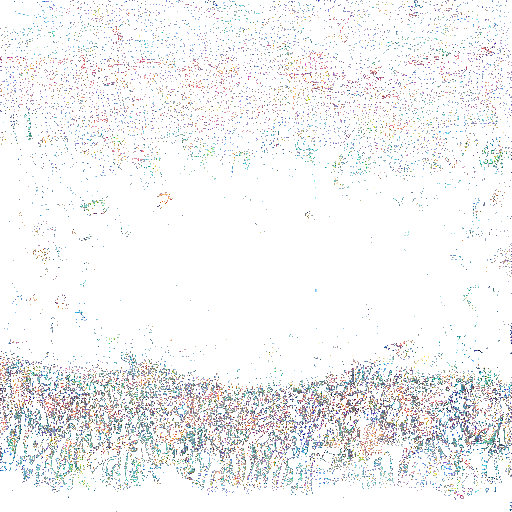

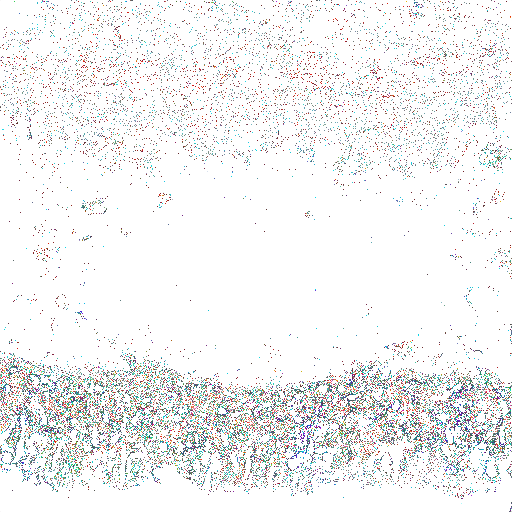

In [17]:
# ==== 推理入口 ====
import torch
from PIL import Image
from IPython.display import display

# 路径 & 设备
CKPT_PATH = "drive/MyDrive/recover1ckpt.pt"   # 你保存的权重
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 与训练完全一致的模型构造参数
def build_model():
    # 注意：需与训练时的超参一致（base=128, ch_mult=(1,2,4,8), time_dim=320, in_channels=6, out_channels=3）
    return ConditionalUNet(base=192, ch_mult=(1,2,4,8),
                           time_dim=320, in_channels=6, out_channels=3).to(DEVICE)

# 加载权重（优先 EMA），严格匹配；若遇到历史权重结构有出入，可把 strict=True 改成 False
model = build_model()
ckpt = torch.load(CKPT_PATH, map_location="cpu")
state = ckpt.get("ema", ckpt.get("model", ckpt))
missing, unexpected = model.load_state_dict(state, strict=False)
if missing or unexpected:
    print("[WARN] missing keys:", missing)
    print("[WARN] unexpected keys:", unexpected)
model.eval()

# 调度器（与训练一致 T=1000）
sched = DiffusionSchedule(T=1000, device=DEVICE)

# 单张图推理：输入 PIL 的漂移图，输出矫正后 PIL
@torch.no_grad()
def infer_one(pil_cond: Image.Image, steps=150, eta=0.0) -> Image.Image:
    cond = preprocess_cond(pil_cond, enforce_size=(512,512)).to(DEVICE)  # [1,3,512,512]
    pred = sample_ddim(model, sched, cond, steps=steps, eta=eta)          # [-1,1], [1,3,512,512]

    # 反归一化 -> PIL
    x = (pred.clamp(-1,1)[0] + 1) * 0.5          # [3,512,512], [0,1]
    x = (x * 255.0).round().clamp(0,255).byte()  # uint8
    arr = x.permute(1,2,0).cpu().numpy()         # HWC
    return Image.fromarray(arr)

# ====== 使用示例 ======
# 把下面的路径换成你的漂移图（偏色图）
test_path = "1.png"
inp = Image.open(test_path).convert("RGB")
out = infer_one(inp, steps=200, eta=0.5)
out.save("1_recover.png")

print("输入 / 输出：")
display(inp)
display(out)
